# Inventory Policies — Service Levels and Effective Horizons

The previous notebooks let the solver find the **profit-optimal** order quantity — the critical fractile of the demand distribution. Sometimes you need to *override* that with an operational constraint:

> *"I don't care if it's not profit-optimal. I need at least a 95 % fill rate on Tablet Air because stockouts damage the brand."*

`PeriodicBaseStock` is the policy class that handles this. It sits on top of `PeriodicOrderUpTo` and adds a per-item cycle-service-level (CSL) floor:

| Responsibility | Mechanism |
|---|---|
| **Service-level floor** | Adds a `NonlinearConstraint` to the trust-region solver: `P(Q_eff ≥ demand) ≥ target` |
| **Effective horizon** | Sets the demand window to `lead_time + review_period` (the classical *protection interval*) |

---

## What this notebook covers

1. **Baseline run** — profit-optimal allocation with `PeriodicOrderUpTo` (no service constraint)
2. **Policy run** — same problem with `PeriodicBaseStock(service_targets={"Tablet Air": 0.95})`
3. **Side-by-side comparison** — quantities, service levels, expected profit, and the cost of the service guarantee
4. **Effective horizon demo** — how `lead_time + review_period` changes the demand window the solver sees
5. **Net orders** — using `inventory_state` to compute what you actually need to place today

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

# ── Synthetic two-year history for two items ───────────────────────────────
#
# Tablet Air — consumer electronics
#   · Moderate upward trend, strong weekend spike, Q4 seasonal wave
#   · Black Friday and Christmas event spikes
#
# Laptop Pro — business laptop
#   · Steeper trend (enterprise demand), mid-week purchasing pattern
#   · Softer seasonal curve, no promotions

N = 730
dates = pd.date_range("2022-01-01", periods=N, freq="D")
t = np.arange(N)

# Tablet Air
trend_ta  = 120 + 0.08 * t
weekly_ta = 18 * np.sin(2 * np.pi * t / 7) + 8 * np.cos(2 * np.pi * t / 7)
yearly_ta = 12 * np.sin(2 * np.pi * t / 365.25) + 8 * np.cos(2 * np.pi * t / 365.25)
event_ta  = np.zeros(N)
for i, d in enumerate(dates):
    if d.month == 11 and d.weekday() == 4 and 22 <= d.day <= 28:
        event_ta[i : min(i + 4, N)] += 80
    if d.month == 12 and 20 <= d.day <= 26:
        event_ta[i] += 60
sales_ta = np.maximum(trend_ta + weekly_ta + yearly_ta + event_ta + np.random.normal(0, 10, N), 5).round(1)

# Laptop Pro
trend_lp  = 80 + 0.12 * t
weekly_lp = 12 * np.sin(2 * np.pi * t / 7) - 6 * np.cos(2 * np.pi * t / 7)
yearly_lp = 8 * np.sin(2 * np.pi * t / 365.25) + 5 * np.cos(2 * np.pi * t / 365.25)
sales_lp  = np.maximum(trend_lp + weekly_lp + yearly_lp + np.random.normal(0, 8, N), 5).round(1)

df_history = pd.concat([
    pd.DataFrame({"item": "Tablet Air", "date": dates.astype(str), "sales": sales_ta}),
    pd.DataFrame({"item": "Laptop Pro",  "date": dates.astype(str), "sales": sales_lp}),
], ignore_index=True)

print(f"History: {len(df_history):,} rows | {df_history['date'].min()} → {df_history['date'].max()}")

History: 1,460 rows | 2022-01-01 → 2023-12-31


## Item Configuration

Two new columns compared to previous notebooks:

- **`lead_time`** — days from order placement to arrival. Each policy class reads this from `Item.Lead_time` when computing the effective planning horizon `lead_time + review_period`.
- Pricing is deliberately asymmetric: Tablet Air has a tighter margin (lower critical fractile), so the profit-optimal quantity will be smaller — making the service-level constraint more likely to bite.

In [2]:
item_configs = pd.DataFrame([
    {
        "name":          "Tablet Air",
        "cost_price":    120,
        "selling_price": 220,   # narrow margin → lower critical fractile
        "salvage_value":  40,
        "lead_time":      5,    # 5-day supplier lead time
    },
    {
        "name":          "Laptop Pro",
        "cost_price":    400,
        "selling_price": 750,   # wide margin → higher critical fractile
        "salvage_value": 100,
        "lead_time":      3,    # 3-day lead time
    },
])

from optistock import PeriodicOrderUpTo, PeriodicBaseStock
from optistock.forecasting.linear_regressors import BayesTimeSeries

seasonal_config = {
    "weekly": (7, 3),
    "yearly": (365.25, 4),
}

events = {
    "Tablet Air": {
        "black_friday": [str(d.date()) for d in dates if d.month == 11 and d.weekday() == 4 and 22 <= d.day <= 28],
        "christmas":    [str(d.date()) for d in dates if d.month == 12 and 20 <= d.day <= 26],
    }
}

for item_cfg in item_configs.itertuples():
    cf = (item_cfg.selling_price - item_cfg.cost_price) / (
         (item_cfg.selling_price - item_cfg.cost_price) + (item_cfg.cost_price - item_cfg.salvage_value)
    )
    print(f"  {item_cfg.name:12s}  critical fractile = {cf:.3f}  lead_time = {item_cfg.lead_time} days")

  Tablet Air    critical fractile = 0.556  lead_time = 5 days
  Laptop Pro    critical fractile = 0.538  lead_time = 3 days


---
## 1. Baseline — Profit-Optimal Allocation (No Service Constraint)

`PeriodicOrderUpTo(review_period=25)` maximises expected profit with no service-level floor. The planning horizon per item is `lead_time + review_period`:
- Tablet Air: 5 + 25 = **30 days**
- Laptop Pro: 3 + 25 = **28 days**

The optimal quantity for each item should sit close to its **critical fractile** of the demand distribution. Tablet Air's critical fractile (~0.55) is lower than Laptop Pro's (~0.54), so the solver will order fewer Tablet Air units relative to its demand distribution.

In [3]:
sk_base = PeriodicOrderUpTo(
    histories=df_history,
    item_configs=item_configs,
    review_period=25,
    forecaster_class=BayesTimeSeries,
    forecaster_kwargs={"seasonal_config": seasonal_config},
)

# 30-day holdout, SAA objective, no service constraint
base_results = sk_base.run_holdout(
    holdout_days=30,
    events=events,
    objective="SAA",
    fit_kwargs={"chain": 2, "samples": 500},
)

print(f"Planning period: {base_results['period']}")
print()
print(f"{'Item':<14} {'Gross order':>12} {'Net order':>10} {'SL (realised)':>14} {'Profit':>12}")
print("-" * 66)
for item in sk_base.items:
    m   = base_results["metrics"][item.name]
    qty = base_results["allocation"][item.name]
    net = base_results["net_allocation"][item.name]
    print(f"{item.name:<14} {qty:>12,} {net:>10,} {m['service_level']:>13.1%}  R{m['profit']:>10,.0f}")

print("-" * 66)
print(f"{'Portfolio profit':>42}  R{base_results['metrics']['portfolio_total_profit']:>10,.0f}")
print()
print("Solver service level (all items):", f"{base_results['solver_summary']['service_level']:.1%}")

Initializing NUTS using jitter+adapt_diag...
c:\Users\bouwe\OneDrive\Desktop\GitCode\OptiStock\.venv\Lib\site-packages\pytensor\link\c\cmodule.py:2986: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options and details see https://pytensor.readthedocs.io/en/latest/troubleshooting.html#how-do-i-configure-test-my-blas-library
  warnings.warn(
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept, growth, beta_event, beta_fourier, sigma]


Output()

Sampling 4 chains for 1_000 tune and 500 draw iterations (4_000 + 2_000 draws total) took 31 seconds.
Sampling: [y]


Output()

Sampling: [y]


...

Sampling: [y]


Output()

C:\Users\bouwe\OneDrive\Desktop\GitCode\OptiStock\src\optistock\stockkeep.py:189: UserWarning: Effective horizon was clamped to 2023-12-29 for items: ['Tablet Air']. Consider running items with different lead times separately.
  return self._run_pipeline(


Planning period: ('2023-12-02', '2023-12-29')

Item            Gross order  Net order  SL (realised)       Profit
------------------------------------------------------------------
Tablet Air            5,642      5,642         96.5%  R   564,200
Laptop Pro            4,687      4,687         91.0%  R 1,640,450
------------------------------------------------------------------
                          Portfolio profit  R 2,204,650

Solver service level (all items): 29.4%


C:\Users\bouwe\OneDrive\Desktop\GitCode\OptiStock\src\optistock\solvers.py:285: RuntimeWarning: divide by zero encountered in divide
  eu = float(np.mean(np.exp(-profits / self.risk_aversion)))


---
## 2. Policy Run — Service-Level Constraint on Tablet Air

`PeriodicBaseStock` extends `PeriodicOrderUpTo` with per-item CSL targets:

```python
PeriodicBaseStock(
    review_period=7,
    service_targets={"Tablet Air": 0.95},  # 95 % fill rate on Tablet Air only
)
```

Two things happen under the hood for Tablet Air:

1. **Effective horizon** = `lead_time(5) + review_period(7)` = **12 days** (instead of 30).
2. **`NonlinearConstraint`** is added to the trust-region solver: `P(Q × yield ≥ demand) ≥ 0.95`.

Current on-hand stock is passed via `inventory_state` so the solver can compute the net order:
`net_order = max(0, gross_order − on_hand − on_order)`

Laptop Pro has no service target — it is optimised purely for profit.

In [4]:
sk_policy = PeriodicBaseStock(
    histories=df_history,
    item_configs=item_configs,
    review_period=7,
    service_targets={"Tablet Air": 0.95},
    forecaster_class=BayesTimeSeries,
    forecaster_kwargs={"seasonal_config": seasonal_config},
)

inventory_state = {"Tablet Air": {"on_hand": 150, "on_order": 0}}

print("PeriodicBaseStock configuration:")
print(f"  review_period   = {sk_policy.review_period} days")
print(f"  service_targets = {sk_policy.service_targets}")
print()
print("Effective horizons (lead_time + review_period):")
for item in sk_policy.items:
    horizon = item.Lead_time + sk_policy.review_period
    print(f"  {item.name:<12}  {item.Lead_time} + {sk_policy.review_period} = {horizon} days")
print()
print("Inventory state (on-hand stock):")
for name, state in inventory_state.items():
    ip = state["on_hand"] + state["on_order"]
    print(f"  {name}: on_hand={state['on_hand']}, on_order={state['on_order']}, inventory_position={ip}")

PeriodicBaseStock configuration:
  review_period   = 7 days
  service_targets = {'Tablet Air': 0.95}

Effective horizons (lead_time + review_period):
  Tablet Air    5 + 7 = 12 days
  Laptop Pro    3 + 7 = 10 days

Inventory state (on-hand stock):
  Tablet Air: on_hand=150, on_order=0, inventory_position=150


In [5]:
policy_results = sk_policy.run_holdout(
    holdout_days=7,
    events=events,
    objective="SAA",
    inventory_state=inventory_state,
    fit_kwargs={"chain": 2, "samples": 500},
)

print(f"Planning period: {policy_results['period']}")
print("(Tablet Air optimization window = effective horizon within holdout)")
print()
print(f"{'Item':<14} {'Gross order':>12} {'Net order':>10} {'SL (realised)':>14} {'Profit':>12}")
print("-" * 66)
for item in sk_policy.items:
    m   = policy_results["metrics"][item.name]
    qty = policy_results["allocation"][item.name]
    net = policy_results["net_allocation"][item.name]
    print(f"{item.name:<14} {qty:>12,} {net:>10,} {m['service_level']:>13.1%}  R{m['profit']:>10,.0f}")

print("-" * 66)
print(f"{'Portfolio profit':>42}  R{policy_results['metrics']['portfolio_total_profit']:>10,.0f}")
print()
print("Solver service level (all items):", f"{policy_results['solver_summary']['service_level']:.1%}")

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept, growth, beta_event, beta_fourier, sigma]


Output()

Sampling 4 chains for 1_000 tune and 500 draw iterations (4_000 + 2_000 draws total) took 26 seconds.
Sampling: [y]


Output()

Sampling: [y]


...

Sampling: [y]


Output()

C:\Users\bouwe\OneDrive\Desktop\GitCode\OptiStock\src\optistock\stockkeep.py:189: UserWarning: Effective horizon was clamped to 2023-12-31 for items: ['Tablet Air', 'Laptop Pro']. Consider running items with different lead times separately.
  return self._run_pipeline(
c:\Users\bouwe\OneDrive\Desktop\GitCode\OptiStock\.venv\Lib\site-packages\scipy\optimize\_differentiable_functions.py:728: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  self.H.update(delta_x, delta_g)


Planning period: ('2023-12-25', '2023-12-31')
(Tablet Air optimization window = effective horizon within holdout)

Item            Gross order  Net order  SL (realised)       Profit
------------------------------------------------------------------
Tablet Air            1,470      1,320        100.0%  R   136,848
Laptop Pro            1,203      1,203         97.3%  R   421,050
------------------------------------------------------------------
                          Portfolio profit  R   557,898

Solver service level (all items): 49.7%


C:\Users\bouwe\OneDrive\Desktop\GitCode\OptiStock\src\optistock\stockkeep.py:461: UserWarning: Service-level constraint may not be fully satisfied (violation=0.0003). Try relaxing service_level_target or increasing MCMC samples.
  allocation = solver.optimize()
C:\Users\bouwe\OneDrive\Desktop\GitCode\OptiStock\src\optistock\solvers.py:285: RuntimeWarning: divide by zero encountered in divide
  eu = float(np.mean(np.exp(-profits / self.risk_aversion)))


---
## 3. Side-by-Side Comparison

The key numbers to look at:

- **Tablet Air gross order**: the policy run should be *higher* — the 95 % service constraint forces the solver above the profit-optimal quantity.
- **Tablet Air net order**: lower than gross because of the 150 units already on hand.
- **Tablet Air service level**: should be ≥ 95 % in the policy run vs whatever the unconstrained critical fractile implied.
- **Portfolio profit**: the policy run may show lower expected profit for Tablet Air (cost of the service guarantee), but higher realised profit if the baseline would have stocked out.
- **Laptop Pro**: identical across both runs — no policy attached.

In [6]:
rows = []
for item in sk_base.items:
    m_base   = base_results["metrics"][item.name]
    m_policy = policy_results["metrics"][item.name]
    rows.append({
        "Item": item.name,
        "Gross (no policy)": base_results["allocation"][item.name],
        "Gross (policy)": policy_results["allocation"][item.name],
        "Net (policy)": policy_results["net_allocation"][item.name],
        "SL no policy": f"{m_base['service_level']:.1%}",
        "SL with policy": f"{m_policy['service_level']:.1%}",
        "Profit no policy": f"R{m_base['profit']:,.0f}",
        "Profit with policy": f"R{m_policy['profit']:,.0f}",
        "Stockout no policy": m_base["stockout"],
        "Stockout with policy": m_policy["stockout"],
    })

df_cmp = pd.DataFrame(rows).set_index("Item")
print(df_cmp.T.to_string())

print()
print(f"Portfolio profit (no policy) : R{base_results['metrics']['portfolio_total_profit']:>12,.0f}")
print(f"Portfolio profit (with policy): R{policy_results['metrics']['portfolio_total_profit']:>12,.0f}")

Item                 Tablet Air  Laptop Pro
Gross (no policy)          5642        4687
Gross (policy)             1470        1203
Net (policy)               1320        1203
SL no policy              96.5%       91.0%
SL with policy           100.0%       97.3%
Profit no policy       R564,200  R1,640,450
Profit with policy     R136,848    R421,050
Stockout no policy         True        True
Stockout with policy      False        True

Portfolio profit (no policy) : R   2,204,650
Portfolio profit (with policy): R     557,898


### Visualise: demand distribution vs Q* for each run

The plot below shows the posterior demand distribution for Tablet Air under both runs, with the respective Q* values marked. The 95th percentile of the distribution (the theoretical CSL floor) is shown as a reference.

- **No-policy Q*** sits near the critical-fractile percentile (≈ 50th for Tablet Air).
- **Policy Q*** is pushed to the right to satisfy `P(Q ≥ demand) ≥ 0.95`.

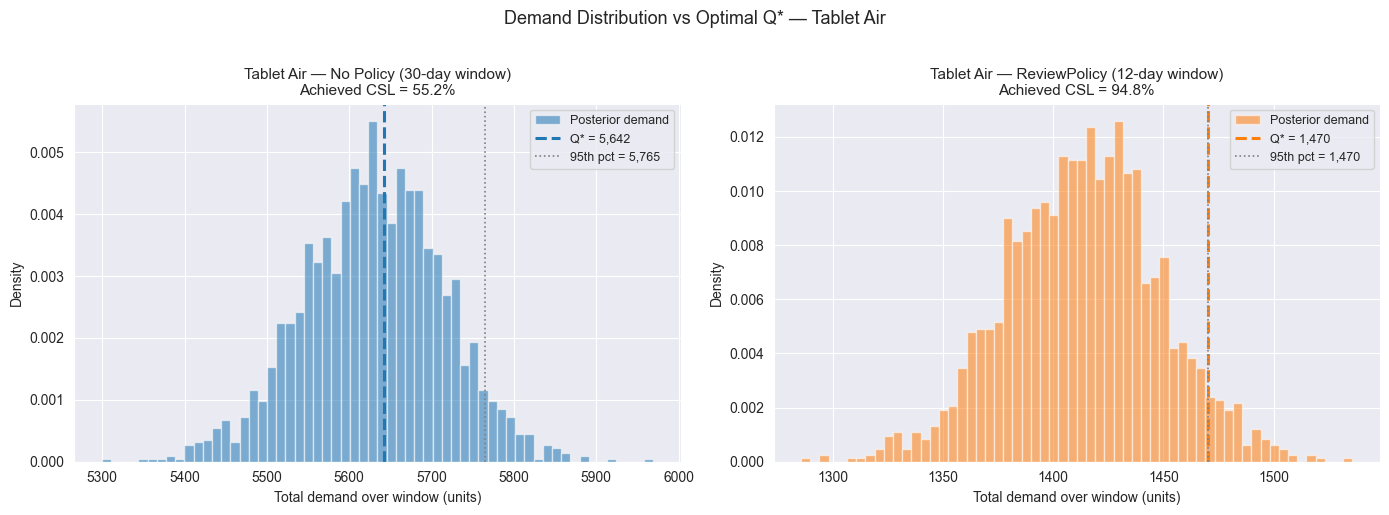

In [7]:
from optistock.plot_suite import solver_to_problems

# Extract demand samples from each solver (same item ordering)
def get_samples(sk, item_name):
    problems = solver_to_problems(sk.solver)
    return next(d.samples for it, d in problems if it.name == item_name)

# Note: policy run has a shorter optimisation window for Tablet Air
# so demand samples represent ~12 days of demand, not 30
samples_base   = get_samples(sk_base,   "Tablet Air")
samples_policy = get_samples(sk_policy, "Tablet Air")

q_base   = base_results["allocation"]["Tablet Air"]
q_policy = policy_results["allocation"]["Tablet Air"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

for ax, samples, q, title, color in [
    (axes[0], samples_base,   q_base,   "No Policy (30-day window)",  "tab:blue"),
    (axes[1], samples_policy, q_policy, "ReviewPolicy (12-day window)", "tab:orange"),
]:
    ax.hist(samples, bins=60, density=True, alpha=0.55, color=color, label="Posterior demand")
    ax.axvline(q, color=color, lw=2.2, linestyle="--", label=f"Q* = {q:,}")
    p95 = float(np.percentile(samples, 95))
    ax.axvline(p95, color="grey", lw=1.2, linestyle=":", label=f"95th pct = {p95:,.0f}")
    sl_achieved = float(np.mean(samples <= q))
    ax.set_title(f"Tablet Air — {title}\nAchieved CSL = {sl_achieved:.1%}", fontsize=11)
    ax.set_xlabel("Total demand over window (units)")
    ax.set_ylabel("Density")
    ax.legend(fontsize=9)

plt.suptitle("Demand Distribution vs Optimal Q* — Tablet Air", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## 4. Effective Horizon Deep-Dive

The two demand histograms above are on **different scales** because the policy changes how much demand the forecaster is asked to aggregate:

| Run | `review_period` | Window | Demand samples represent |
|---|---|---|---|
| No constraint | 25 | 30 days (Tablet Air) | Total demand over 30 days |
| With constraint | 7 | 12 days (Tablet Air) | Total demand over 12 days |

The planning horizon (`lead_time + review_period`) is the key parameter. The solver is only responsible for covering demand until the *next replenishment can arrive*. Ordering beyond that ties up capital that a future replenishment cycle will cover.

The cell below computes effective horizons directly from the policy object.

In [8]:
# Inspect how PeriodicBaseStock translates operational parameters → solver inputs

# Grab the demand samples the policy solver actually used for Tablet Air
samples_12d = samples_policy

print("=" * 55)
print("PeriodicBaseStock: Tablet Air")
print("=" * 55)
tablet = next(it for it in sk_policy.items if it.name == "Tablet Air")
effective_horizon = tablet.Lead_time + sk_policy.review_period
service_target = sk_policy.service_targets.get("Tablet Air", 0.0)

print(f"  lead_time         = {tablet.Lead_time} days")
print(f"  review_period     = {sk_policy.review_period} days")
print(f"  effective_horizon = {effective_horizon} days")
print(f"  service_target    = {service_target:.0%}")
print()
print("Demand samples (12-day window):")
print(f"  mean  = {samples_12d.mean():,.0f} units")
print(f"  std   = {samples_12d.std():,.0f} units")
print(f"  p50   = {np.percentile(samples_12d, 50):,.0f} units")
print(f"  p95   = {np.percentile(samples_12d, 95):,.0f} units")
print()
min_qty = float(np.quantile(samples_12d, service_target))
print(f"Solver lower bound (95th pct of demand):")
print(f"  min_quantity = {min_qty:,.0f} units")
print()
print("Net order accounting:")
gross = policy_results["allocation"]["Tablet Air"]
net   = policy_results["net_allocation"]["Tablet Air"]
on_hand  = inventory_state["Tablet Air"]["on_hand"]
on_order = inventory_state["Tablet Air"]["on_order"]
inv_pos  = on_hand + on_order
print(f"  gross order        = {gross:,} units (solver output)")
print(f"  on_hand            = {on_hand:,} units")
print(f"  on_order           = {on_order:,} units")
print(f"  inventory_position = {inv_pos:,} units")
print(f"  net order          = max(0, {gross} − {inv_pos}) = {net} units")

PeriodicBaseStock: Tablet Air
  lead_time         = 5 days
  review_period     = 7 days
  effective_horizon = 12 days
  service_target    = 95%

Demand samples (12-day window):
  mean  = 1,413 units
  std   = 35 units
  p50   = 1,414 units
  p95   = 1,470 units

Solver lower bound (95th pct of demand):
  min_quantity = 1,470 units

Net order accounting:
  gross order        = 1,470 units (solver output)
  on_hand            = 150 units
  on_order           = 0 units
  inventory_position = 150 units
  net order          = max(0, 1470 − 150) = 1320 units


---
## 5. Cost of the Service Guarantee

Every extra unit ordered above the profit-optimal quantity costs money: you pay procurement cost upfront and may salvage at a loss. This is the **cost of the service guarantee** — the premium you pay to avoid stockouts.

The plot below shows the expected profit curve for Tablet Air as a function of order quantity. The profit-optimal Q* (no policy) and the service-constrained Q* (policy) are both marked.

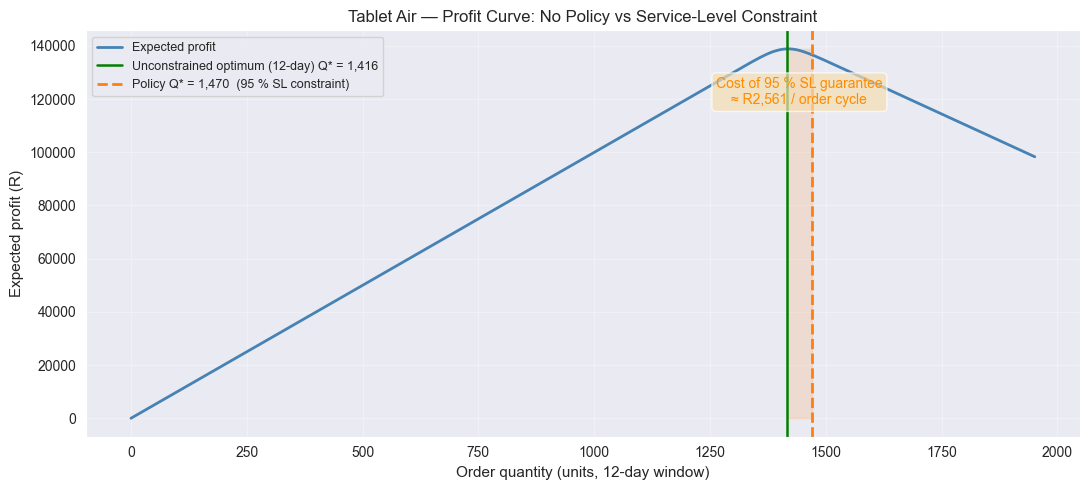

Profit at unconstrained Q*  : R138,891
Profit at policy Q*         : R136,330
Cost of 95 % SL guarantee   : R2,561 per 12-day order cycle


In [9]:
# Compute expected profit curve for Tablet Air using the policy solver's samples
item_ta = next(it for it in sk_policy.items if it.name == "Tablet Air")
yield_samples = sk_policy.solver._yield_matrix[
    [it.name for it, _ in sk_policy.solver.problems].index("Tablet Air")
]

demand_12d = sk_policy.solver._demand_matrix[
    [it.name for it, _ in sk_policy.solver.problems].index("Tablet Air")
]

q_range = np.linspace(0, int(np.percentile(demand_12d, 99.5)) * 1.3, 300)
profits = []
for q in q_range:
    q_eff  = q * yield_samples
    sales  = np.minimum(q_eff, demand_12d)
    left   = q_eff - sales
    profit = np.mean(
        sales * item_ta.selling_price
        + left * item_ta.salvage_value
        - q   * item_ta.cost_price
    )
    profits.append(profit)

profits = np.array(profits)

# Unconstrained profit-optimal Q (12-day window for comparability)
q_opt_idx = np.argmax(profits)
q_opt     = q_range[q_opt_idx]

q_no_policy = base_results["allocation"]["Tablet Air"]
q_with_pol  = policy_results["allocation"]["Tablet Air"]

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(q_range, profits, color="steelblue", lw=2, label="Expected profit")
ax.axvline(q_opt, color="green", lw=1.8, linestyle="-",
           label=f"Unconstrained optimum (12-day) Q* = {q_opt:,.0f}")
ax.axvline(q_with_pol, color="tab:orange", lw=2, linestyle="--",
           label=f"Policy Q* = {q_with_pol:,}  (95 % SL constraint)")

# Shade the cost of the service guarantee
ax.fill_betweenx(
    [profits.min(), profits[q_opt_idx]],
    q_opt, q_with_pol,
    alpha=0.15, color="tab:orange",
)
profit_at_opt = profits[q_opt_idx]
profit_at_pol = profits[np.searchsorted(q_range, q_with_pol)]
cost_of_sl = profit_at_opt - profit_at_pol
ax.annotate(
    f"Cost of 95 % SL guarantee\n≈ R{cost_of_sl:,.0f} / order cycle",
    xy=((q_opt + q_with_pol) / 2, profit_at_opt * 0.85),
    ha="center", fontsize=10, color="darkorange",
    bbox=dict(boxstyle="round,pad=0.3", fc="wheat", alpha=0.7),
)

ax.set_xlabel("Order quantity (units, 12-day window)", fontsize=11)
ax.set_ylabel("Expected profit (R)", fontsize=11)
ax.set_title("Tablet Air — Profit Curve: No Policy vs Service-Level Constraint", fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Profit at unconstrained Q*  : R{profit_at_opt:,.0f}")
print(f"Profit at policy Q*         : R{profit_at_pol:,.0f}")
print(f"Cost of 95 % SL guarantee   : R{cost_of_sl:,.0f} per 12-day order cycle")

---
## 6. Net Orders — What You Actually Place Today

The solver outputs a **gross order quantity** — the total stock level needed. What you actually need to *order* today is the gross quantity minus what you already have (on-hand + on-order).

Pass `inventory_state={"item_name": {"on_hand": N, "on_order": M}}` to `run()` or `run_holdout()`. `StockKeep` returns both `allocation` (gross) and `net_allocation` (what to order today) in the result dict. Items without an `inventory_state` entry have `net_allocation == allocation`.

In [10]:
print("Gross vs Net Order Quantities (Policy Run)")
print("=" * 58)
print(f"{'Item':<14} {'Gross':>8}  {'On hand':>8}  {'On order':>9}  {'Net':>8}")
print("-" * 58)

for item in sk_policy.items:
    gross = policy_results["allocation"][item.name]
    net   = policy_results["net_allocation"][item.name]
    state = inventory_state.get(item.name, {})
    on_hand  = state.get("on_hand", 0)
    on_order = state.get("on_order", 0)
    print(f"{item.name:<14} {gross:>8,}  {on_hand:>8,}  {on_order:>9,}  {net:>8,}")

print()
print("Note: Laptop Pro has no inventory_state entry, so gross == net.")

Gross vs Net Order Quantities (Policy Run)
Item              Gross   On hand   On order       Net
----------------------------------------------------------
Tablet Air        1,470       150          0     1,320
Laptop Pro        1,203         0          0     1,203

Note: Laptop Pro has no inventory_state entry, so gross == net.


---
## Summary

| Concept | What it does | How it's expressed |
|---|---|---|
| `PeriodicOrderUpTo(review_period)` | Profit-optimal periodic review | Planning horizon = `lead_time + review_period` |
| `PeriodicBaseStock(review_period, service_targets)` | Adds CSL floors on top of `PeriodicOrderUpTo` | `service_targets={"item": 0.95}` |
| **Effective horizon** | Sets demand window = `lead_time + review_period` | Computed automatically per item |
| **Service-level constraint** | Forces `P(Q_eff ≥ demand) ≥ target` | `NonlinearConstraint` in the trust-region solver |
| **Lower bound (warm-start)** | 95th-pct floor on gross order, improves solver convergence | Built from `service_targets` quantile |
| **Net order** | What to actually place today | `inventory_state` passed to `run()`/`run_holdout()` |
| **`net_allocation`** | Net orders for all items in result dict | `result['net_allocation'][item_name]` |

### Key trade-off

The service-level constraint always has a **profit cost**: the solver is forced to order above the critical fractile, buying inventory that is more likely to be left over than sold. The profit curve section quantifies this trade-off and helps set the service-level target at the right point on the profit–service frontier.

### Choosing between `PeriodicOrderUpTo` and `PeriodicBaseStock`

| Use case | Class |
|---|---|
| Pure profit optimisation, no service guarantee | `PeriodicOrderUpTo` |
| One or more items need a CSL floor | `PeriodicBaseStock` |
| Items with on-hand stock to deduct | Either class + `inventory_state` in `run()` |